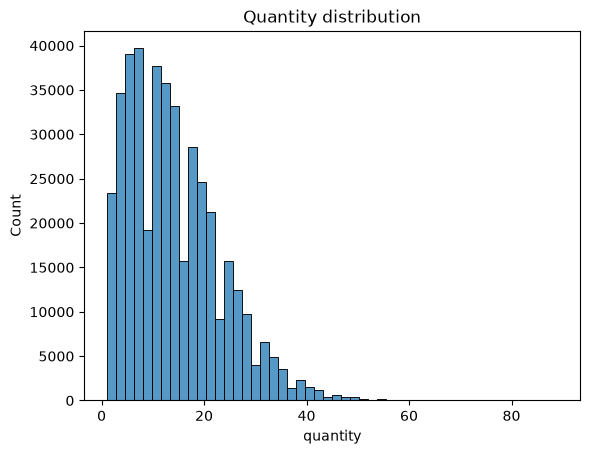

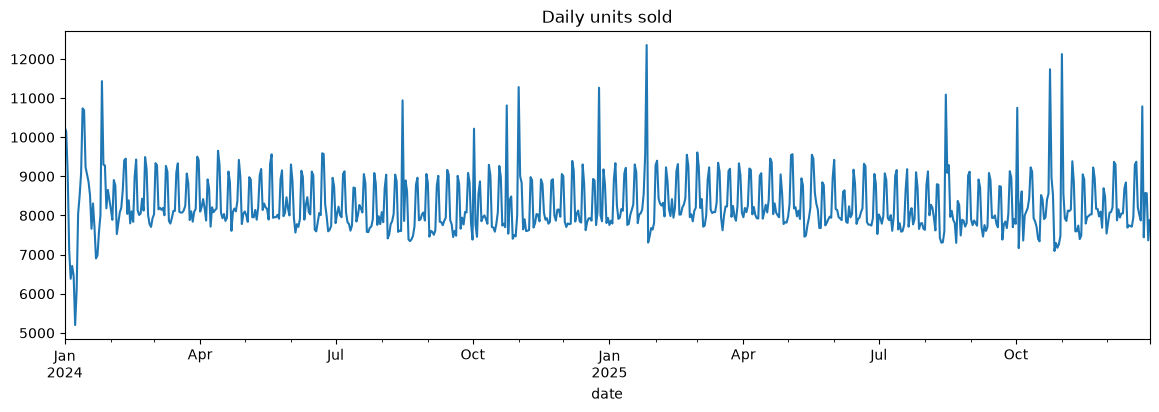

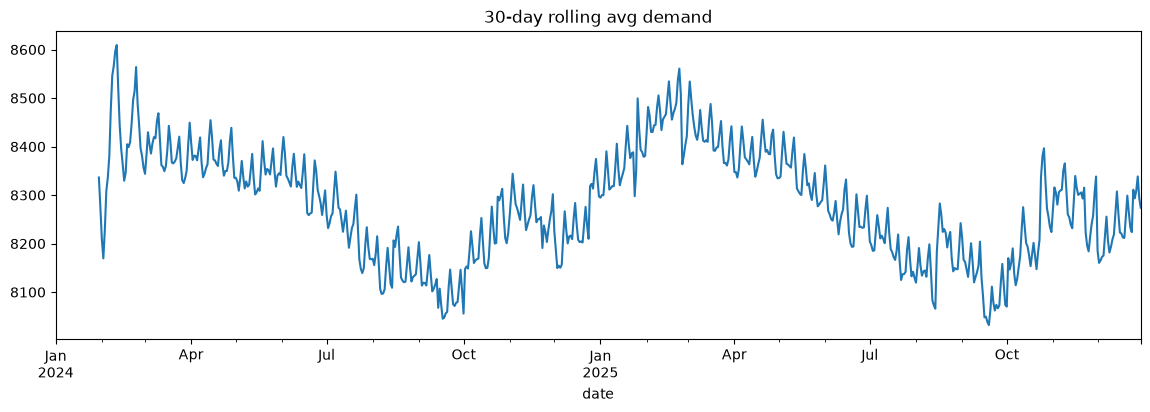

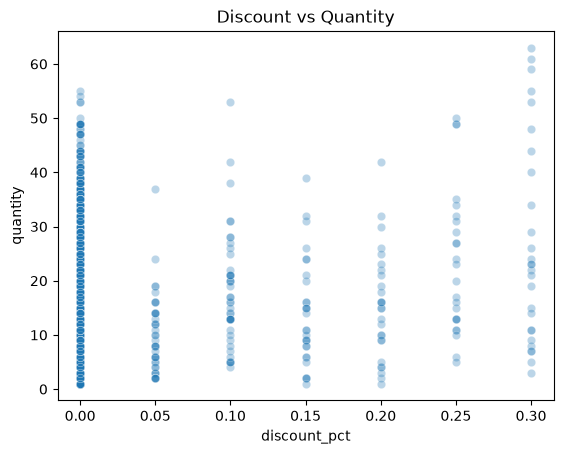

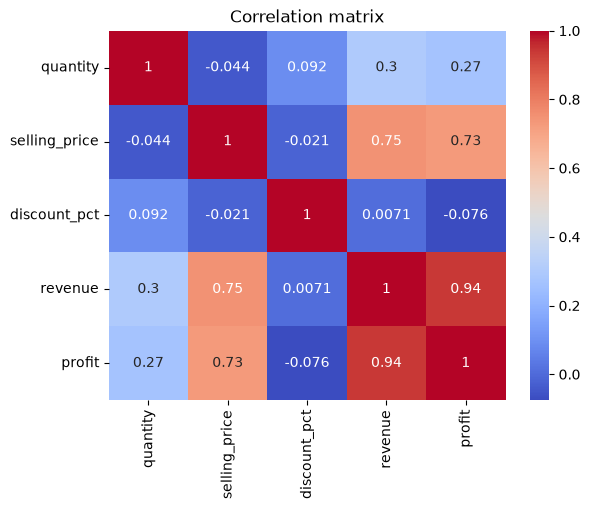

t=38.83, p=0.00000


In [4]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sales = pd.read_csv("../data/processed/fact_sales_clean.csv", parse_dates=["date"])
inv = pd.read_csv("../data/raw/fact_inventory.csv", parse_dates=["date"])
product = pd.read_csv("../data/raw/dim_product.csv")

# Univariate
sales["quantity"].describe()
sns.histplot(sales["quantity"], bins=50); plt.title("Quantity distribution"); plt.show()

# Daily demand time series
daily = sales.groupby("date")["quantity"].sum()
daily.plot(figsize=(14,4), title="Daily units sold"); plt.show()

# Rolling trend (spot seasonality)
daily.rolling(30).mean().plot(figsize=(14,4), title="30-day rolling avg demand"); plt.show()

# Bivariate: discount vs quantity (does discount actually move units?)
sns.scatterplot(data=sales.sample(5000), x="discount_pct", y="quantity", alpha=0.3)
plt.title("Discount vs Quantity"); plt.show()

# Correlation matrix
numeric_cols = sales[["quantity","selling_price","discount_pct","revenue","profit"]]
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation matrix"); plt.show()

# Correlation ≠ causation check: compare promo vs non-promo demand with a t-test
promo_qty = sales[sales.promotion_id.notna()]["quantity"]
non_promo_qty = sales[sales.promotion_id.isna()]["quantity"]
t_stat, p_val = stats.ttest_ind(promo_qty, non_promo_qty, equal_var=False)
print(f"t={t_stat:.2f}, p={p_val:.5f}")
# p < 0.05 → the uplift during promotions is statistically significant, not noise